In [1]:
# Core imports for the whole lab
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.0.2


In [2]:
# 1. Probability theory & axioms

In [3]:
# -----------------------------------------------------------
# 🔹 1A. PROBABILITY BY SIMULATION
# -----------------------------------------------------------

# P(A) = favourable outcomes / total outcomes.
# We can estimate it by simulating many trials.
rolls = np.random.randint(1, 7, size=100_000)   # 100k dice rolls

p_even = (rolls % 2 == 0).mean()       # P(even)
p_gt4  = (rolls > 4).mean()            # P(roll > 4)
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [4]:
# -----------------------------------------------------------
# 🔹 1B. THE ADDITION RULE (disjoint events)
# -----------------------------------------------------------

# Rolling a 1 OR a 2 — these events can't both happen (disjoint)
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [5]:
# LAB EXERCISE 1 — Probability by simulation

In [6]:
import numpy as np

# Simulate flipping two coins 100,000 times
flips = np.random.randint(0, 2, size=(100_000, 2))   # 0 = tails, 1 = heads
heads = flips.sum(axis=1)   # number of heads in each pair (0, 1, 2)


# 1. P(both heads) -> heads == 2

p_both_heads = np.mean(heads == 2)

print("P(both heads):", p_both_heads)

P(both heads): 0.25198


In [7]:
# 2. P(at least one head) -> heads >= 1

p_at_least_one_head = np.mean(heads >= 1)

print("P(at least one head):", p_at_least_one_head)

P(at least one head): 0.74932


In [8]:
# 3. Check P(0) + P(1) + P(2) = 1

p_0_heads = np.mean(heads == 0)
p_1_head = np.mean(heads == 1)
p_2_heads = np.mean(heads == 2)

total_probability = p_0_heads + p_1_head + p_2_heads

print("\nP(0 heads):", p_0_heads)
print("P(1 head):", p_1_head)
print("P(2 heads):", p_2_heads)

print("Sum of probabilities:", total_probability)

if np.isclose(total_probability, 1):
    print("Yes, P(0)+P(1)+P(2) sums to 1.")
else:
    print("No, probabilities do not sum to 1.")


P(0 heads): 0.25068
P(1 head): 0.49734
P(2 heads): 0.25198
Sum of probabilities: 1.0
Yes, P(0)+P(1)+P(2) sums to 1.


In [9]:
# 2. Conditional probability & independence

In [10]:
# -----------------------------------------------------------
# 🔹 2A. CONDITIONAL PROBABILITY  P(A | B) = P(A and B) / P(B)
# -----------------------------------------------------------

rolls = np.random.randint(1, 7, size=100_000)

# P(roll is 6 | roll is even):  narrow the world to even rolls
even = rolls[rolls % 2 == 0]          # condition on 'even'
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.332  (true 1/3)


In [11]:
# -----------------------------------------------------------
# 🔹 2B. TESTING FOR INDEPENDENCE
# -----------------------------------------------------------

# Two events are independent if P(A|B) == P(A).
# 'roll > 3' and 'roll is even' -> are they independent?
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.498
P(A | B)  = 0.666
Independent? False


In [12]:
# LAB EXERCISE 2 — Conditional probability

In [13]:
import numpy as np

# Fresh dice rolls
rolls = np.random.randint(1, 7, size=100_000)


# 1. P(odd | roll < 4)
# Condition on rolls < 4, then check odd

condition = rolls < 4

p_odd_given_less_than_4 = np.mean(rolls[condition] % 2 == 1)

print("P(odd | roll < 4):", p_odd_given_less_than_4)

P(odd | roll < 4): 0.667995991983968


In [15]:
# 2. P(roll < 4)

p_less_than_4 = np.mean(rolls < 4)

print("P(roll < 4):", p_less_than_4)

P(roll < 4): 0.499


In [16]:
# 3. Compare P(odd | <4) with P(odd) overall

p_odd = np.mean(rolls % 2 == 1)

print("P(odd):", p_odd)

if np.isclose(p_odd_given_less_than_4, p_odd, atol=0.01):
    print("The events are independent.")
else:
    print("The events are not independent.")

P(odd): 0.50253
The events are not independent.


In [1]:
# 3. Bayes' theorem

In [2]:
# -----------------------------------------------------------
# 🔹 3A. THE MEDICAL-TEST PROBLEM (by formula)
# -----------------------------------------------------------

# Disease affects 1% of people; test is 99% accurate.
p_disease   = 0.01                       # prior  P(D)
p_pos_given_D  = 0.99                     # true positive rate  P(+|D)
p_pos_given_nD = 0.01                     # false positive rate P(+|not D)

# P(+) = P(+|D)P(D) + P(+|notD)P(notD)   (total probability)
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

# Bayes: P(D | +)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [4]:
# -----------------------------------------------------------
# 🔹 3B. THE SAME ANSWER BY SIMULATION (sanity check)
# -----------------------------------------------------------
import numpy as np

N = 1_000_000
has_disease = np.random.rand(N) < p_disease
# test result depends on disease status
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,    # sick -> 99% positive
                     np.random.rand(N) < p_pos_given_nD)   # healthy -> 1% positive

among_positive = has_disease[tests_pos]      # of those who tested positive...
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.501


In [5]:
# LAB EXERCISE 3 — A Bayes scenario (spam filter)

In [6]:
# -----------------------------------------------------------
# 🔹 SPAM FILTER BAYES PROBLEM
# -----------------------------------------------------------

# Prior probability
p_spam = 0.20                 # P(Spam)
p_not_spam = 1 - p_spam       # P(Not Spam)

# Likelihoods
p_free_given_spam = 0.60      # P("free"|Spam)
p_free_given_not_spam = 0.05  # P("free"|Not Spam) - false positive rate


# 1. Compute P("free") using total probability rule
#
# P(free) = P(free|Spam)P(Spam) + P(free|NotSpam)P(NotSpam)

p_free = (p_free_given_spam * p_spam) + \
         (p_free_given_not_spam * p_not_spam)

print('P("free") =', round(p_free, 3))


P("free") = 0.16


In [7]:
# 2. Apply Bayes theorem
#
# P(Spam|free) = P(free|Spam)P(Spam) / P(free)

p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print('P(Spam | "free") =', round(p_spam_given_free, 3))

P(Spam | "free") = 0.75


In [8]:
# 4. Probability distributions

In [11]:
import numpy as np
from scipy import stats
# Bernoulli: a single yes/no trial with probability p
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')

Bernoulli(0.3) mean ~ 0.303 (true 0.3)
Poisson(4) mean ~ 3.989 (true 4)


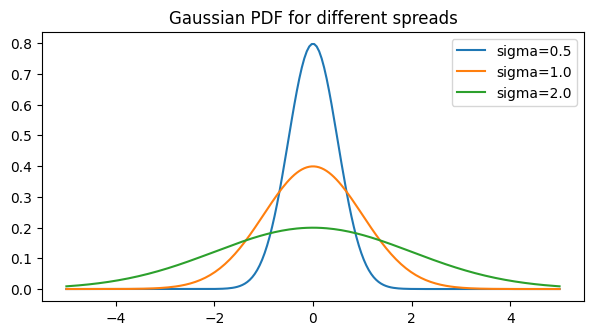

In [13]:
# -----------------------------------------------------------
# 🔹 4B. THE GAUSSIAN (normal) — plot the bell curve
# -----------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

In [14]:
# LAB EXERCISE 4 — Simulate & plot distributions

In [15]:
# -----------------------------------------------------------
# 🔹 Poisson Simulation + Gaussian PDF Plot
# -----------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


# 1. Draw 10,000 samples from Poisson distribution (mu=2)

poisson_samples = stats.poisson(mu=2).rvs(size=10_000)

print("Poisson(2) sample mean ~", round(poisson_samples.mean(), 3))

Poisson(2) sample mean ~ 1.984


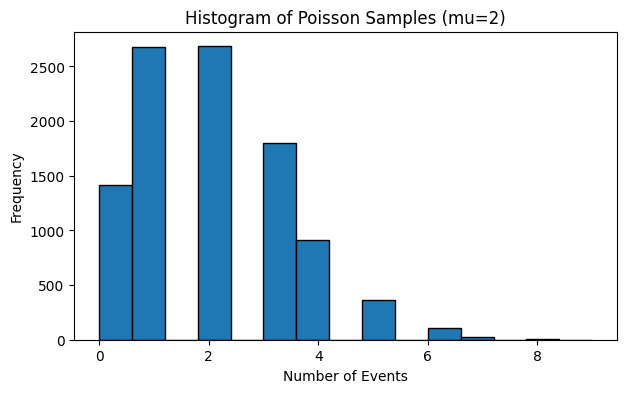

In [16]:
# 2. Plot histogram of Poisson samples

plt.figure(figsize=(7,4))

plt.hist(poisson_samples, bins=15, edgecolor='black')

plt.title("Histogram of Poisson Samples (mu=2)")
plt.xlabel("Number of Events")
plt.ylabel("Frequency")

plt.show()

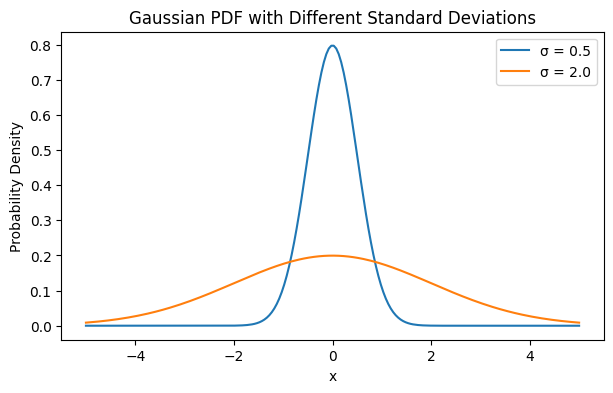

In [17]:
# 3. Plot Gaussian PDF for mu=0 with two different sigmas

x = np.linspace(-5, 5, 200)

plt.figure(figsize=(7,4))

for sigma in [0.5, 2.0]:
    plt.plot(
        x,
        stats.norm(0, sigma).pdf(x),
        label=f"σ = {sigma}"
    )

plt.title("Gaussian PDF with Different Standard Deviations")
plt.xlabel("x")
plt.ylabel("Probability Density")

plt.legend()
plt.show()


# Observation:
# Smaller sigma (0.5) produces a narrow and tall curve.
# Larger sigma (2.0) produces a wider and flatter curve.

In [18]:
# 5. Entropy, KL divergence & mutual information

In [19]:
# -----------------------------------------------------------
# 🔹 5A. ENTROPY — how uncertain is a distribution?
# -----------------------------------------------------------

from scipy.stats import entropy

fair   = [0.5, 0.5]      # a fair coin: maximum uncertainty
biased = [0.9, 0.1]      # a biased coin: more predictable
certain= [1.0, 0.0]      # no uncertainty at all

# base=2 gives entropy in BITS
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [20]:
# -----------------------------------------------------------
# 🔹 5B. KL DIVERGENCE — how far is Q from P?
# -----------------------------------------------------------

P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

# scipy's entropy(P, Q) computes the KL divergence D(P || Q)
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [21]:
# -----------------------------------------------------------
# 🔹 5C. MUTUAL INFORMATION — which feature is most informative?
# -----------------------------------------------------------

from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [22]:
# LAB EXERCISE 5 — Information theory

In [23]:
# -----------------------------------------------------------
# 🔹 Entropy, KL Divergence and Iris MI Interpretation
# -----------------------------------------------------------

import numpy as np
from scipy.stats import entropy


# 1. Entropy of fair 4-sided and 6-sided die (base=2)

# Fair 4-sided die
fair_4 = np.ones(4) / 4
entropy_4 = entropy(fair_4, base=2)

# Fair 6-sided die
fair_6 = np.ones(6) / 6
entropy_6 = entropy(fair_6, base=2)

print("Entropy of fair 4-sided die:", round(entropy_4, 3), "bits")
print("Entropy of fair 6-sided die:", round(entropy_6, 3), "bits")

if entropy_6 > entropy_4:
    print("The fair 6-sided die is more uncertain.")
else:
    print("The fair 4-sided die is more uncertain.")

Entropy of fair 4-sided die: 2.0 bits
Entropy of fair 6-sided die: 2.585 bits
The fair 6-sided die is more uncertain.


In [24]:
# 2. KL divergence D(P || Q)

P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])

kl_div = entropy(P, Q, base=2)

print("\nKL Divergence D(P || Q):", round(kl_div, 3), "bits")


KL Divergence D(P || Q): 0.119 bits


In [25]:
# 3. Most / least informative iris feature (from MI scores)
# Example based on typical Iris mutual information results:

# Most informative: petal length / petal width
# Least informative: sepal width